In [57]:
!pip install transformers datasets scikit-learn torch pandas matplotlib seaborn -q
!pip install tensorflow -q
!pip install transformers

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

import torch
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

LECTURA DE LOS DATASET

In [59]:
fake_df = pd.read_csv("Fake.csv", on_bad_lines='skip', engine='python')
true_df = pd.read_csv("True.csv", on_bad_lines='skip', engine='python')

ETIQUETAS DE SALIDSA

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
fake_df["label"] = 0
true_df["label"] = 1

DATASETS CONCATENACION

In [62]:
df = pd.concat([fake_df, true_df])

#
df = df.sample(n=4000, random_state=42)

df = df.sample(frac=1).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,JOHN KASICH Suspends Campaign After Coming In ...,Wow! John Kasich finally got the message and i...,politics,"May 4, 2016",0
1,State Department to conduct internal probe of ...,WASHINGTON (Reuters) - The U.S. State Departme...,politicsNews,"July 8, 2016",1
2,JILL STEIN (HILLARY’S) Recount Collapses: Miss...,Jill Stein got less than 1% of the vote nation...,left-news,"Nov 29, 2016",0
3,GREAT PICK! KT McFarland To Join Team Trump [V...,In asking KT McFarland to become his Deputy N...,politics,"Nov 25, 2016",0
4,"One U.S. attack is not enough, says Syrian opp...",BEIRUT (Reuters) - The Syrian opposition appla...,politicsNews,"April 7, 2017",1


tamaño

In [63]:
print(df.shape)

(4000, 5)


la distribucuon de los datos

In [64]:
df["label"].value_counts()

,count
label,
0,2123
1,1877


clases graficas

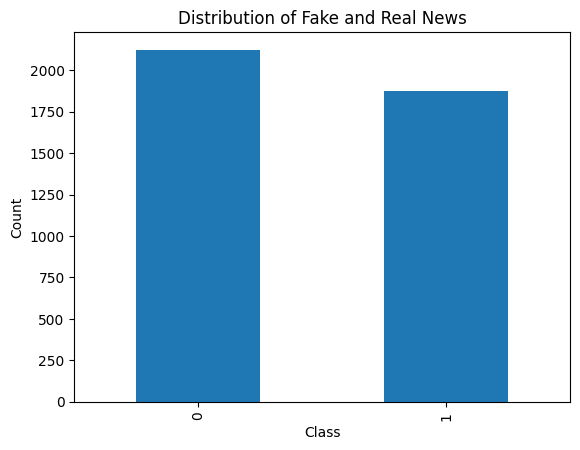

In [65]:
df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Fake and Real News")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

titulo, texto

In [66]:
df["content"] = df["title"] + " " + df["text"]

In [67]:
import re

def limpiar_fuga_reuters(texto):

    texto_limpio = re.sub(r'^.*?Reuters\s*[-—:\s]\s*', '', texto, flags=re.IGNORECASE)

    texto_limpio = re.sub(r'\bReuters\b', '', texto_limpio, flags=re.IGNORECASE)

    return texto_limpio

df['text'] = df['text'].apply(limpiar_fuga_reuters)

x e y

In [68]:
X = df["content"]
y = df["label"]

In [69]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'content'], dtype='object')


division del dataset

In [70]:
from sklearn.model_selection import train_test_split

X = df['content']
y = df['label']

# Esto te mostrará en pantalla qué etiquetas tienes exactamente y cuántas hay de cada una
print("Conteo de mis etiquetas:")
print(y.value_counts())
print("-" * 30)

# PRIMERA DIVISIÓN: Quitamos 'stratify=y' para evitar el error
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# SEGUNDA DIVISIÓN: Quitamos 'stratify=y' aquí también
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Textos para Entrenar: {len(X_train)}")
print(f"Textos para Validar: {len(X_val)}")
print(f"Textos para Probar: {len(X_test)}")

Conteo de mis etiquetas:
label
0    2123
1    1877
Name: count, dtype: int64
------------------------------
Textos para Entrenar: 2800
Textos para Validar: 600
Textos para Probar: 600


In [71]:
import re

def limpiar_fuga_reuters(texto):

    texto_limpio = re.sub(r'^.*?Reuters\s*[-—:\s]\s*', '', texto, flags=re.IGNORECASE)


    texto_limpio = re.sub(r'\bReuters\b', '', texto_limpio, flags=re.IGNORECASE)

    return texto_limpio

df['text'] = df['text'].apply(limpiar_fuga_reuters)

TF-IDF

In [72]:
import random

sinonimos = {
    "good": "great",
    "bad": "terrible",
    "government": "administration",
    "president": "leader",
    "said": "stated",
    "news": "report"
}

def augmentar_texto(texto):

    palabras = texto.split()

    nuevas_palabras = []

    for palabra in palabras:

        palabra_lower = palabra.lower()

        if palabra_lower in sinonimos and random.random() < 0.3:
            nuevas_palabras.append(sinonimos[palabra_lower])
        else:
            nuevas_palabras.append(palabra)

    return " ".join(nuevas_palabras)

X_train_aug = X_train.apply(augmentar_texto)

X_train_final = pd.concat([
    X_train,
    X_train_aug
])

y_train_final = pd.concat([
    y_train,
    y_train
])

In [73]:
vectorizer = TfidfVectorizer(max_features=10000)

X_train_tfidf = vectorizer.fit_transform(X_train_final)
X_test_tfidf = vectorizer.transform(X_test)

baseline model

In [74]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_tfidf, y_train_final)

LogisticRegression(max_iter=1000)

predicciones

In [75]:
baseline_predictions = baseline_model.predict(X_test_tfidf)

metricas

In [76]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)

print("Baseline F1-Score:", baseline_f1)

print(classification_report(y_test, baseline_predictions))

Baseline Accuracy: 0.975
Baseline F1-Score: 0.9732620320855615
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       322
           1       0.96      0.98      0.97       278

    accuracy                           0.97       600
   macro avg       0.97      0.98      0.97       600
weighted avg       0.98      0.97      0.98       600



MODELO LSTM

In [77]:
tokenizer_lstm = Tokenizer(num_words=10000)

tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)

X_test_seq = tokenizer_lstm.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=200)

X_test_pad = pad_sequences(X_test_seq, maxlen=200)

lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=10000, output_dim=64)
)

lstm_model.add(
    LSTM(64)
)

lstm_model.add(
    Dense(1, activation='sigmoid')
)

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=2,
    batch_size=32,
    validation_split=0.1
)

lstm_predictions = (
    lstm_model.predict(X_test_pad) > 0.5
).astype("int32")

lstm_accuracy = accuracy_score(
    y_test,
    lstm_predictions
)

lstm_f1 = f1_score(
    y_test,
    lstm_predictions
)

print("LSTM Accuracy:", lstm_accuracy)

print("LSTM F1-Score:", lstm_f1)

Epoch 1/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8321 - loss: 0.3752 - val_accuracy: 0.9429 - val_loss: 0.1624
Epoch 2/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9770 - loss: 0.0722 - val_accuracy: 0.9607 - val_loss: 0.1197
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
LSTM Accuracy: 0.9683333333333334
LSTM F1-Score: 0.9658886894075404


MODELO BERT

In [78]:
## separar validacio n
train_texts, val_texts, train_labels, val_labels = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42
)

cargar tokenizer

In [79]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

tokenizacin

In [80]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

creacion dataset huggingface

In [81]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": list(train_labels)
})

val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": list(val_labels)
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": list(y_test)
})

cargar el bert

In [82]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


configuracion de entrenamiento

In [83]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_dir="./logs",

    learning_rate=2e-5
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainer

In [84]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset
)

entrenamiento del modelo

In [85]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.024182
2,0.028249,0.000083
3,0.028249,0.000299


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=945, training_loss=0.015004000560474143, metrics={'train_runtime': 263.1187, 'train_samples_per_second': 28.732, 'train_steps_per_second': 3.592, 'total_flos': 497279894630400.0, 'train_loss': 0.015004000560474143, 'epoch': 3.0})

evaluacion

In [86]:
predictions = trainer.predict(test_dataset)

bert_predictions = np.argmax(
    predictions.predictions,
    axis=1
)

metricas bert

In [87]:
bert_accuracy = accuracy_score(
    y_test,
    bert_predictions
)

bert_f1 = f1_score(
    y_test,
    bert_predictions
)

print("BERT Accuracy:", bert_accuracy)

print("BERT F1-Score:", bert_f1)

print(classification_report(
    y_test,
    bert_predictions
))

BERT Accuracy: 1.0
BERT F1-Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00       278

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [88]:
def agregar_errores(texto):

    palabras = texto.split()

    nuevas = []

    for palabra in palabras:

        if len(palabra) > 4 and random.random() < 0.2:

            palabra = palabra[:-1]

        nuevas.append(palabra)

    return " ".join(nuevas)

X_test_ruido = X_test.apply(agregar_errores)

test_ruido_encodings = tokenizer(
    list(X_test_ruido),
    truncation=True,
    padding=True,
    max_length=128
)

test_ruido_dataset = Dataset.from_dict({
    "input_ids": test_ruido_encodings["input_ids"],
    "attention_mask": test_ruido_encodings["attention_mask"],
    "labels": list(y_test)
})

predictions_ruido = trainer.predict(test_ruido_dataset)

bert_predictions_ruido = np.argmax(
    predictions_ruido.predictions,
    axis=1
)

print("Accuracy con errores ortográficos:")
print(accuracy_score(
    y_test,
    bert_predictions_ruido
))

Accuracy con errores ortográficos:
1.0


comparacion

In [89]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LSTM",
        "BERT"
    ],

    "Accuracy": [
        baseline_accuracy,
        lstm_accuracy,
        bert_accuracy
    ],

    "F1-Score": [
        baseline_f1,
        lstm_f1,
        bert_f1
    ]
})

results

,Model,Accuracy,F1-Score
0,Logistic Regression,0.975000,0.973262
1,LSTM,0.968333,0.965889
2,BERT,1.000000,1.000000
